In [1]:
%load_ext cuml.accel
import pandas as pd

ModuleNotFoundError: No module named 'cuml'

# 读取数据集

In [3]:
user_data = pd.read_csv('data/JD_IJCAI 19/user')
item_data = pd.read_csv('data/JD_IJCAI 19/item_info')
user_click_data = pd.read_csv('data/JD_IJCAI 19/user_click')
user_order_data = pd.read_csv('data/JD_IJCAI 19/user_order')

C:\Users\lenovo\AppData\Local\Temp\ipykernel_16860\3492151259.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  user_click_data = pd.read_csv('data/JD_IJCAI 19/user_click')


In [3]:
# 查看用户数据
user_data.head()

,user_id,gender,age_range
0,0,0,21~25
1,1,0,31~35
2,2,0,26~30
3,3,1,46~50
4,4,1,31~35


In [4]:
# 查看商品数据
item_data.head()

,item_id,cid1,cid2,cid3,cid1_name,cid2_name,cid3_name,brand_code,price,item_name,seg_name
0,100000002008,1315,1345,12015,服饰内衣,内衣,秋衣秋裤,12002.0,199.0,马克华菲保暖内衣 男士秋衣秋裤套装薄款棉质高弹棉毛衫秋冬男生线衣线裤 宝蓝圆领 L,内衣 高弹 男士 套装 秋衣 棉毛衫 宝蓝 线衣 薄款 秋裤 马克华菲 男生 保暖 棉质 线...
1,100000002009,6196,6227,6232,厨具,餐具,一次性用品,57642.0,19.9,乐扣乐扣 PE家用一次性保鲜膜 生鲜食品保鲜薄膜 LBM106*3 (3卷装)20cm*20M,保鲜膜 薄膜 20cm 生鲜 pe 保鲜 家用 20m 食品 卷装 一次性 乐扣乐扣
2,100000002011,6196,6227,6232,厨具,餐具,一次性用品,57642.0,18.9,乐扣乐扣 PE生鲜水果用一次性保鲜膜 厨房家用保鲜薄膜 LBM105*2(两卷装)30cm*20M,20m 保鲜 厨房 生鲜水果 pe 一次性 薄膜 30cm 乐扣乐扣 两卷装 家用 保鲜膜
3,100000002012,1315,1345,9744,服饰内衣,内衣,男式内裤,8439.0,199.0,花花公子男士内裤冰丝平角内裤男网眼透气弹力中腰四角裤男 4条装5370多色L,男士 弹力 多色 中腰 网眼 内裤 透气 冰丝 花花公子 四角裤 平角 4条装
4,100000002013,6196,11143,11153,厨具,茶具,茶具配件,18922.0,79.0,雅集智能恒温宝 加热保温茶杯垫 玻璃杯垫暖奶器茶具电热保温底座,雅集 茶杯垫 加热 电热 茶具 暖奶器 杯垫 保温 恒温宝 底座 玻璃 智能


In [5]:
# 查看点击数据
user_click_data.head()

,user_id,item_id,datetime,dt
0,0,1150551,2018-06-10 21:41:31,2018-06-10
1,0,11133236,2018-06-10 22:15:15,2018-06-10
2,0,6888601,2018-06-10 21:57:31,2018-06-10
3,0,5812383,2018-06-10 21:40:22,2018-06-10
4,0,4803330,2018-06-10 21:40:07,2018-06-10


In [6]:
# 查看订单数据
user_order_data.head()

,user_id,item_id,count,datetime,dt
0,0,4803330,2,2018-06-10 22:11:02,2018-06-10
1,0,6743054,1,2018-06-10 22:11:02,2018-06-10
2,0,4803334,2,2018-06-10 22:11:02,2018-06-10
3,0,6888601,1,2018-06-10 22:11:02,2018-06-10
4,0,2518073,2,2018-06-10 22:11:02,2018-06-10


# 数据基本信息


In [4]:
print('用户数据形状:', user_data.shape)
print('用户数据列:', user_data.columns.tolist())
print('商品数据形状:', item_data.shape)
print('商品数据列:', item_data.columns.tolist())
print('点击数据形状:', user_click_data.shape)
print('点击数据列:', user_click_data.columns.tolist())
print('订单数据形状:', user_order_data.shape)
print('订单数据列:', user_order_data.columns.tolist())

用户数据形状: (100000, 3)
用户数据列: ['user_id', 'gender', 'age_range']
商品数据形状: (6827234, 11)
商品数据列: ['item_id', 'cid1', 'cid2', 'cid3', 'cid1_name', 'cid2_name', 'cid3_name', 'brand_code', 'price', 'item_name', 'seg_name']
点击数据形状: (52983323, 4)
点击数据列: ['user_id', 'item_id', 'datetime', 'dt']
订单数据形状: (1458498, 5)
订单数据列: ['user_id', 'item_id', 'count', 'datetime', 'dt']


In [5]:
# 数据完整性验证
print('商品数据缺失值:')
print(item_data.isnull().sum())
print('缺失率:')
print(item_data.isnull().sum() / len(item_data) * 100)

商品数据缺失值:
item_id             0
cid1                0
cid2                0
cid3                0
cid1_name           0
cid2_name           0
cid3_name           0
brand_code      37427
price         2050186
item_name           1
seg_name       856682
dtype: int64
缺失率:
item_id        0.000000
cid1           0.000000
cid2           0.000000
cid3           0.000000
cid1_name      0.000000
cid2_name      0.000000
cid3_name      0.000000
brand_code     0.548202
price         30.029526
item_name      0.000015
seg_name      12.548010
dtype: float64


In [9]:
# 数据质量评估
print('用户数据基本统计:')
print(user_data.describe())
print('商品数据基本统计:')
print(item_data.describe())
print('点击数据基本统计:')
print(user_click_data.describe())
print('订单数据基本统计:')
print(user_order_data.describe())

用户数据基本统计:
             user_id         gender
count  100000.000000  100000.000000
mean    49999.500000       0.405000
std     28867.657797       0.490894
min         0.000000       0.000000
25%     24999.750000       0.000000
50%     49999.500000       0.000000
75%     74999.250000       1.000000
max     99999.000000       1.000000
商品数据基本统计:
            item_id          cid1          cid2          cid3    brand_code  \
count  6.827234e+06  6.827234e+06  6.827234e+06  6.827234e+06  6.789807e+06   
mean   2.154335e+10  4.862532e+03  6.390071e+03  8.372509e+03  1.205616e+05   
std    1.664265e+10  4.847746e+03  5.173076e+03  4.784336e+03  1.132162e+05   
min    1.000120e+05  1.730000e+02  1.810000e+02  4.340000e+02 -1.000000e+00   
25%    1.102751e+10  1.315000e+03  1.343000e+03  3.982000e+03  1.504200e+04   
50%    2.360775e+10  1.620000e+03  6.167000e+03  9.733000e+03  8.625600e+04   
75%    2.998756e+10  9.192000e+03  1.173100e+04  1.204700e+04  2.122610e+05   
max    2.001248e+11  1.7

# KNN插补price字段

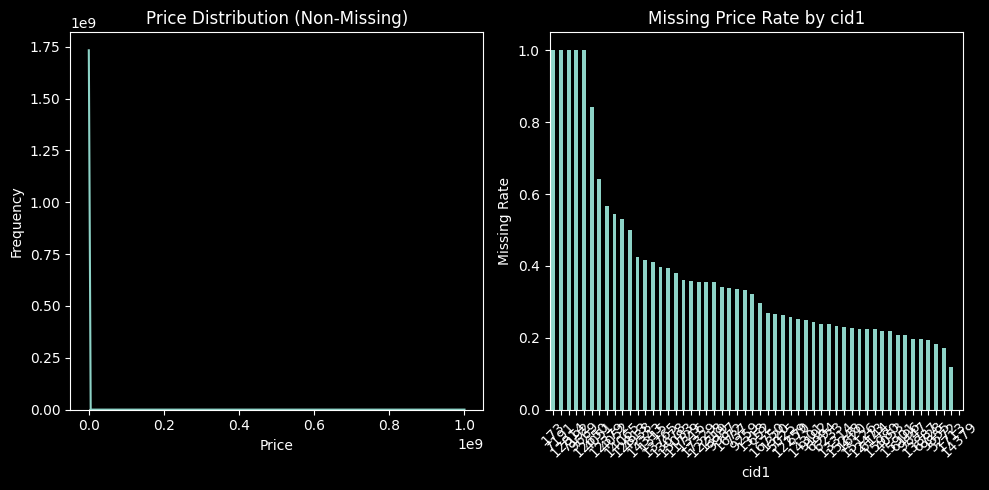

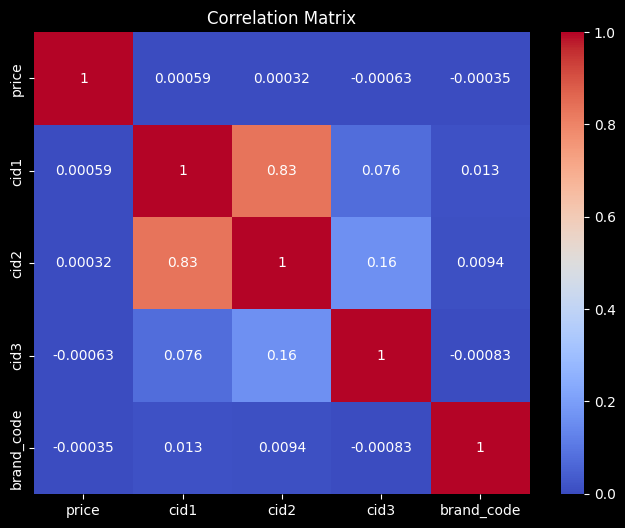

In [7]:
# 分析price分布和缺失模式
import matplotlib.pyplot as plt
import seaborn as sns

# price分布
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(item_data['price'].dropna(), bins=50, kde=True)
plt.title('Price Distribution (Non-Missing)')
plt.xlabel('Price')
plt.ylabel('Frequency')

# 缺失值与类别的关系
plt.subplot(1, 2, 2)
missing_by_cid1 = item_data.groupby('cid1')['price'].apply(lambda x: x.isnull().mean()).sort_values(ascending=False)
missing_by_cid1.plot(kind='bar')
plt.title('Missing Price Rate by cid1')
plt.xlabel('cid1')
plt.ylabel('Missing Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 相关性分析
numerical_cols = ['price']  # 如果有其他数值列，添加
categorical_cols = ['cid1', 'cid2', 'cid3', 'brand_code']
# 编码类别查看相关性
from sklearn.preprocessing import LabelEncoder
temp_data = item_data.copy()
for col in categorical_cols:
    le = LabelEncoder()
    temp_data[col] = le.fit_transform(temp_data[col].astype(str))
corr_matrix = temp_data[numerical_cols + categorical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [8]:
# 准备数据：编码类别，标准化
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 选择特征
features = ['cid1', 'cid2', 'cid3', 'brand_code', 'price']
impute_data = item_data[features].copy()

# 编码类别
le_dict = {}
for col in ['cid1', 'cid2', 'cid3', 'brand_code']:
    le = LabelEncoder()
    impute_data[col] = le.fit_transform(impute_data[col].astype(str))
    le_dict[col] = le

# 标准化
scaler = StandardScaler()
impute_data_scaled = scaler.fit_transform(impute_data)

# 分离有缺失和无缺失用于调参
complete_data = impute_data.dropna()
missing_data = impute_data[impute_data['price'].isnull()]

print('Complete data shape:', complete_data.shape)
print('Missing data shape:', missing_data.shape)

Complete data shape: (4777048, 5)
Missing data shape: (2050186, 5)


In [9]:
# 优化KNN参数：交叉验证选择最佳n_neighbors
from sklearn.impute import KNNImputer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
import numpy as np

# 使用完整数据模拟缺失来评估
# 随机选择一些非缺失值设为缺失，评估插补误差
np.random.seed(42)
complete_scaled = scaler.transform(complete_data)
test_indices = np.random.choice(len(complete_scaled), size=int(0.2 * len(complete_scaled)), replace=False)
test_data = complete_scaled[test_indices].copy()
train_data = np.delete(complete_scaled, test_indices, axis=0)

# 模拟缺失
test_data[:, -1] = np.nan  # price列

# 合并训练和测试
combined = np.vstack([train_data, test_data])
true_prices = combined[:, -1].copy()

# 测试不同k
k_values = [3, 5, 7, 9, 11]
rmse_scores = []

for k in k_values:
    imputer = KNNImputer(n_neighbors=k)
    imputed = imputer.fit_transform(combined)
    imputed_prices = imputed[len(train_data):, -1]  # 测试部分
    rmse = np.sqrt(mean_squared_error(true_prices[len(train_data):], imputed_prices))
    rmse_scores.append(rmse)
    print(f'k={k}, RMSE={rmse:.4f}')

best_k = k_values[np.argmin(rmse_scores)]
print(f'Best k: {best_k}')

KeyboardInterrupt: 

In [ ]:
# 应用KNN插补
imputer = KNNImputer(n_neighbors=best_k)
imputed_scaled = imputer.fit_transform(impute_data_scaled)

# 逆标准化
imputed_data = scaler.inverse_transform(imputed_scaled)

# 更新item_data
item_data['price'] = imputed_data[:, -1]

print('插补后price缺失值:', item_data['price'].isnull().sum())
print('插补后price统计:')
print(item_data['price'].describe())

In [ ]:
# 验证插补结果
# 分布对比
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(item_data['price'], bins=50, kde=True, color='blue', label='Imputed')
plt.title('Price Distribution After Imputation')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()

# 与类别相关性
plt.subplot(1, 2, 2)
corr_after = temp_data[numerical_cols + categorical_cols].corr()
sns.heatmap(corr_after, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix After Imputation')
plt.tight_layout()
plt.show()

# 检查异常值或合理性
print('Price range:', item_data['price'].min(), 'to', item_data['price'].max())
print('Negative prices?', (item_data['price'] < 0).sum())

# 如果有下游任务，测试影响
# 例如，简单回归预测price基于类别
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = temp_data[['cat1', 'cat2', 'cat3', 'brand']]
y = temp_data['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('R2 score on imputed data:', r2_score(y_test, y_pred))